# Avaliação Final — Piloto de Cobrança Preventiva (BemLar)

Este notebook é o **esqueleto** da sua entrega. Os blocos abaixo dizem *o que* precisa ser feito; o código é seu.

Antes de escrever qualquer linha:
1. Leia `00_email_financeiro.md` inteiro.
2. Leia `dicionario.md` inteiro.
3. Abra os cinco CSVs e **olhe os valores**, não só os nomes das colunas.

> A entrega vale mais pelas decisões registradas do que pelo código. Cada bloco marcado com ❓ pede uma resposta escrita — responda em célula markdown, ali mesmo.

---
## Fase 1 — Entendimento do Negócio

❓ Em uma frase, qual é a pergunta de negócio? Qual é a unidade de análise (o que é uma linha)?

❓ O Ricardo fez 5 pedidos no e-mail. Liste os 5 e, para cada um, marque agora sua intenção: **atender**, **atender com ressalva** ou **recusar**. Você pode mudar de ideia depois — mas registre a versão inicial.

1. A pergunta do negócio é: para quais clientes eu devo ligar para que os contratos que possuo não virem prejuízo? No caso da análise, na tabela final uma linha repesentará um cliente da empresa.

2. Pedidos do Ricardo:
    - Maior acurácia possível: Vamos atender, mas tendo em vista que acurácia é uma métrica que nem sempre é confiável, pois ela causa a ilusão de alta performance e pode favorecer classes mais frequentes;
    - Uso do campo "status_contrato": Iremos considerar;
    - Uso das informações de sexo e localização: Não iremos considerar as duas colunas, pois no contexto de treino de modelos, informações sensíveis como essas podem reforçar preconceitos e produzir modelos que carregam estigmas prejudiciais por natureza;
    - Uso do score bureau: Iremos considerar;
    - Uso da lista de motivos de atraso: Iremos considerar.

---
## Fase 2 — Entendimento dos Dados

Carregue os cinco arquivos. Lembre: separador `;`, decimal `,`, datas `dd/mm/aaaa`.

Para **cada** base, responda:
- Qual é a granularidade (o que é uma linha)?
- Quantos contratos ela cobre? Todos, ou só uma parte?
- O que significa um valor vazio nessa base? Sempre a mesma coisa?

❓ Faça um inventário de problemas de qualidade: nulos, valores impossíveis, categorias que deveriam ser a mesma. Registre em uma tabela: problema | onde | quantas linhas | é erro ou artefato | o que você fez.

In [3]:
import pandas as pd
import numpy as np

# Convenções de extração definidas no dicionário de dados:
KW = dict(sep=";", decimal=",", encoding="utf-8")

# 1. Carregamento dos 5 arquivos CSV principais
contratos = pd.read_csv("contratos.csv", **KW)
pagamentos = pd.read_csv("pagamentos.csv", **KW)
compras = pd.read_csv("compras.csv", **KW)
ocorrencias_sac = pd.read_csv("ocorrencias_sac.csv", **KW)
score_bureau = pd.read_csv("score_bureau.csv", **KW)

# 2. Conversão das colunas de data com pd.to_datetime (formato dd/mm/aaaa)
contratos["data_venda"] = pd.to_datetime(contratos["data_venda"], format="%d/%m/%Y")
contratos["data_snapshot"] = pd.to_datetime(contratos["data_snapshot"], format="%d/%m/%Y")

pagamentos["data_vencimento"] = pd.to_datetime(pagamentos["data_vencimento"], format="%d/%m/%Y")
pagamentos["data_pagamento"] = pd.to_datetime(pagamentos["data_pagamento"], format="%d/%m/%Y")

compras["data_compra"] = pd.to_datetime(compras["data_compra"], format="%d/%m/%Y")

ocorrencias_sac["data_ocorrencia"] = pd.to_datetime(ocorrencias_sac["data_ocorrencia"], format="%d/%m/%Y")

score_bureau["data_consulta"] = pd.to_datetime(score_bureau["data_consulta"], format="%d/%m/%Y")

# 3. Diagnóstico e apuração dos 5 DataFrames
total_contratos = contratos["id_contrato"].nunique()
clientes_compras = set(compras["id_cliente"])
contratos_compras = contratos[contratos["id_cliente"].isin(clientes_compras)]["id_contrato"].nunique()

diagnostico = [
    {
        "Base": "contratos.csv",
        "Linhas": len(contratos),
        "Colunas": len(contratos.columns),
        "Granularidade": "1 linha por contrato de crediário",
        "Contratos Cobertos": f"{contratos['id_contrato'].nunique()} ({contratos['id_contrato'].nunique()/total_contratos*100:.1f}%)",
        "Valores Nulos": "0 nulos (100% preenchido)"
    },
    {
        "Base": "pagamentos.csv",
        "Linhas": len(pagamentos),
        "Colunas": len(pagamentos.columns),
        "Granularidade": "1 linha por parcela vencida até o snapshot",
        "Contratos Cobertos": f"{pagamentos['id_contrato'].nunique()} ({pagamentos['id_contrato'].nunique()/total_contratos*100:.1f}%)",
        "Valores Nulos": f"data_pagamento: {pagamentos['data_pagamento'].isnull().sum()} ({pagamentos['data_pagamento'].isnull().mean()*100:.2f}%) [parcela não paga]"
    },
    {
        "Base": "compras.csv",
        "Linhas": len(compras),
        "Colunas": len(compras.columns),
        "Granularidade": "1 linha por compra adicional do cliente na rede",
        "Contratos Cobertos": f"{contratos_compras} ({contratos_compras/total_contratos*100:.1f}% via id_cliente)",
        "Valores Nulos": "0 nulos no arquivo (379 contratos s/ compras adicionais)"
    },
    {
        "Base": "ocorrencias_sac.csv",
        "Linhas": len(ocorrencias_sac),
        "Colunas": len(ocorrencias_sac.columns),
        "Granularidade": "1 linha por atendimento/chamado no SAC",
        "Contratos Cobertos": f"{ocorrencias_sac['id_contrato'].nunique()} ({ocorrencias_sac['id_contrato'].nunique()/total_contratos*100:.1f}%)",
        "Valores Nulos": "0 nulos no arquivo (1.011 contratos sem SAC)"
    },
    {
        "Base": "score_bureau.csv",
        "Linhas": len(score_bureau),
        "Colunas": len(score_bureau.columns),
        "Granularidade": "1 linha por consulta de bureau de crédito",
        "Contratos Cobertos": f"{score_bureau['id_contrato'].nunique()} ({score_bureau['id_contrato'].nunique()/total_contratos*100:.1f}%)",
        "Valores Nulos": "0 nulos (100% preenchido)"
    }
]

df_diagnostico = pd.DataFrame(diagnostico)
df_diagnostico


,Base,Linhas,Colunas,Granularidade,Contratos Cobertos,Valores Nulos
0,contratos.csv,3000,14,1 linha por contrato de crediário,3000 (100.0%),0 nulos (100% preenchido)
1,pagamentos.csv,28861,5,1 linha por parcela vencida até o snapshot,3000 (100.0%),data_pagamento: 1690 (5.86%) [parcela não paga]
2,compras.csv,3983,4,1 linha por compra adicional do cliente na rede,2621 (87.4% via id_cliente),0 nulos no arquivo (379 contratos s/ compras a...
3,ocorrencias_sac.csv,3446,4,1 linha por atendimento/chamado no SAC,1989 (66.3%),0 nulos no arquivo (1.011 contratos sem SAC)
4,score_bureau.csv,4490,4,1 linha por consulta de bureau de crédito,3000 (100.0%),0 nulos (100% preenchido)


### Respostas às perguntas da Fase 2 — Entendimento dos Dados

#### 1. `contratos.csv`
- **Granularidade:** Uma linha por **contrato de crediário**. A chave primária única é `id_contrato`.
- **Cobertura de contratos:** Cobre **3.000 contratos (100% da base)**. Abrange 1.824 clientes únicos (`id_cliente`).
- **Apuração de valores nulos:** **0 valores nulos** em todas as 14 colunas. O cadastro e as condições de contratação estão completamente preenchidos.

---

#### 2. `pagamentos.csv`
- **Granularidade:** Uma linha por **parcela já vencida até a data do snapshot (15/03/2026)**. Chave composta por `(id_contrato, n_parcela)`.
- **Cobertura de contratos:** Cobre **3.000 contratos (100% da base)**. Todo contrato do cadastro possui ao menos uma parcela vencida registrada (total de 28.861 parcelas).
- **Apuração de valores nulos:** Apenas a coluna `data_pagamento` possui valores vazios: **1.690 valores nulos** (5,86% do total de parcelas).
  - *O que significa o valor vazio?* **É um artefato de negócio, não um erro:** indica que a parcela já venceu e **ainda não foi paga** até a data do corte (15/03/2026). As demais 4 colunas não têm valores nulos.

---

#### 3. `compras.csv`
- **Granularidade:** Uma linha por **compra adicional realizada pelo cliente na rede** (à vista ou em outro crediário). A chave de ligação é `id_cliente` (e não `id_contrato`).
- **Cobertura de contratos:** Cobre **1.493 clientes únicos (81,9% dos 1.824 clientes)**, correspondendo a **2.621 contratos (87,4% dos 3.000 contratos)**. Há **379 contratos (12,6%)** cujos clientes não possuem outras compras registradas nessa base.
- **Apuração de valores nulos:** **0 valores nulos** no arquivo bruto (4 colunas preenchidas).
  - *O que significa a ausência na junção?* Ao cruzar com a base de contratos via `id_cliente`, os 379 contratos sem compras geram nulos que significam **ausência de evento** (o cliente não efetuou compras extras na rede). Na engenharia de features, devem ser tratados com zero (`qtd_compras = 0`, `total_gasto = 0.0`), e não como dados faltantes.

---

#### 4. `ocorrencias_sac.csv`
- **Granularidade:** Uma linha por **atendimento/ocorrência registrada no SAC** vinculada a um contrato.
- **Cobertura de contratos:** Cobre **1.989 contratos únicos (66,3% dos 3.000 contratos)**. Um total de **1.011 contratos (33,7%)** não possui nenhuma ocorrência registrada no SAC.
- **Apuração de valores nulos:** **0 valores nulos** no arquivo bruto.
  - *O que significa a ausência na junção?* Os 1.011 contratos sem registro refletem **ausência de evento** (o cliente nunca acionou o SAC). Na agregação de variáveis preditivas, ausência de contato vira contagem 0 de ocorrências.

---

#### 5. `score_bureau.csv`
- **Granularidade:** Uma linha por **consulta de bureau de crédito (Serasa/SPC)** referente ao contrato. Um mesmo contrato pode ter mais de uma consulta em momentos diferentes (são 4.490 consultas para 3.000 contratos).
- **Cobertura de contratos:** Cobre **3.000 contratos (100% da base)**. Todos os contratos possuem ao menos uma consulta registrada.
- **Apuração de valores nulos:** **0 valores nulos** em todas as 4 colunas.
  - *Atenção metodológica:* Como há múltiplos registros por contrato, ao criar features é mandatório filtrar consultas realizadas **até a data de referência** de cada contrato (`filtra_por_data`), evitando vazamento temporal (*data leakage*).


In [4]:
# Inventário de qualidade de dados: nulos, valores impossíveis e categorias inconsistentes

inventario = [
    {
        "Problema": "Valores nulos em data de pagamento",
        "Onde": "pagamentos.csv (data_pagamento)",
        "Quantas linhas": f"{pagamentos['data_pagamento'].isnull().sum()} parcelas ({pagamentos['data_pagamento'].isnull().mean()*100:.2f}%)",
        "É erro ou artefato?": "Artefato de negócio",
        "O que você fez": "Mantido nulo no histórico; usado para calcular o alvo (inadimplência) e features de atraso."
    },
    {
        "Problema": "Renda declarada igual a R$ 0,00",
        "Onde": "contratos.csv (renda_declarada)",
        "Quantas linhas": f"{(contratos['renda_declarada'] == 0).sum()} contratos",
        "É erro ou artefato?": "Dado suspeito / sem comprovação formal",
        "O que você fez": "Avaliar se reflete desemprego/informalidade ou imputar com a mediana."
    },
    {
        "Problema": "Categoria quase duplicada de bairro",
        "Onde": "contratos.csv (bairro)",
        "Quantas linhas": f"{(contratos['bairro'] == 'Jd. America').sum()} linhas 'Jd. America' vs {(contratos['bairro'] == 'Jardim América').sum()} 'Jardim América'",
        "É erro ou artefato?": "Erro de digitação / falta de padronização",
        "O que você fez": "Padronizar 'Jd. America' para 'Jardim América' (caso bairro seja utilizado, respeitando a auditoria ética)."
    },
    {
        "Problema": "Ausência de histórico de compras adicionais",
        "Onde": "compras.csv (merge via id_cliente)",
        "Quantas linhas": f"{total_contratos - contratos_compras} contratos ({(total_contratos - contratos_compras)/total_contratos*100:.2f}%)",
        "É erro ou artefato?": "Ausência de evento",
        "O que você fez": "Preencher contagem de compras e volume financeiro com 0 no merge."
    },
    {
        "Problema": "Ausência de chamados de atendimento",
        "Onde": "ocorrencias_sac.csv (merge via id_contrato)",
        "Quantas linhas": f"{total_contratos - ocorrencias_sac['id_contrato'].nunique()} contratos ({(total_contratos - ocorrencias_sac['id_contrato'].nunique())/total_contratos*100:.2f}%)",
        "É erro ou artefato?": "Ausência de evento",
        "O que você fez": "Preencher contagem de chamados com 0 no merge."
    },
    {
        "Problema": "Ausência de chaves de identificação",
        "Onde": "motivos_atraso.csv",
        "Quantas linhas": "1.019 linhas",
        "É erro ou artefato?": "Limitação de extração",
        "O que você fez": "Não incluir na modelagem tabular por impossibilidade de cruzamento com contratos."
    }
]

df_inventario = pd.DataFrame(inventario)
df_inventario


,Problema,Onde,Quantas linhas,É erro ou artefato?,O que você fez
0,Valores nulos em data de pagamento,pagamentos.csv (data_pagamento),1690 parcelas (5.86%),Artefato de negócio,Mantido nulo no histórico; usado para calcular...
1,"Renda declarada igual a R$ 0,00",contratos.csv (renda_declarada),4 contratos,Dado suspeito / sem comprovação formal,Avaliar se reflete desemprego/informalidade ou...
2,Categoria quase duplicada de bairro,contratos.csv (bairro),232 linhas 'Jd. America' vs 429 'Jardim América',Erro de digitação / falta de padronização,Padronizar 'Jd. America' para 'Jardim América'...
3,Ausência de histórico de compras adicionais,compras.csv (merge via id_cliente),379 contratos (12.63%),Ausência de evento,Preencher contagem de compras e volume finance...
4,Ausência de chamados de atendimento,ocorrencias_sac.csv (merge via id_contrato),1011 contratos (33.70%),Ausência de evento,Preencher contagem de chamados com 0 no merge.
5,Ausência de chaves de identificação,motivos_atraso.csv,1.019 linhas,Limitação de extração,Não incluir na modelagem tabular por impossibi...


---
## Fase 3.0 — Tratamento dos Dados

Na Fase 2 foi identificado **4 contratos com `renda_declarada = 0`** — um valor implausível, já que a BemLar concedeu crediário a esses clientes (se a renda fosse realmente zero, o crédito não teria sido aprovado).

Precisamos decidir: **imputar pela média ou pela mediana?**

A escolha depende da **forma da distribuição**. Se for simétrica, média e mediana são próximas e ambas servem. Se for assimétrica (skewed), a média é puxada pelos extremos e a mediana é mais robusta.

Contratos com renda = 0: 4
Contratos com renda > 0: 2996
Média  (sem zeros): R$ 3,068.73
Mediana (sem zeros): R$ 2,823.22
Diferença (média - mediana): R$ 245.51
Assimetria (skewness): 1.36



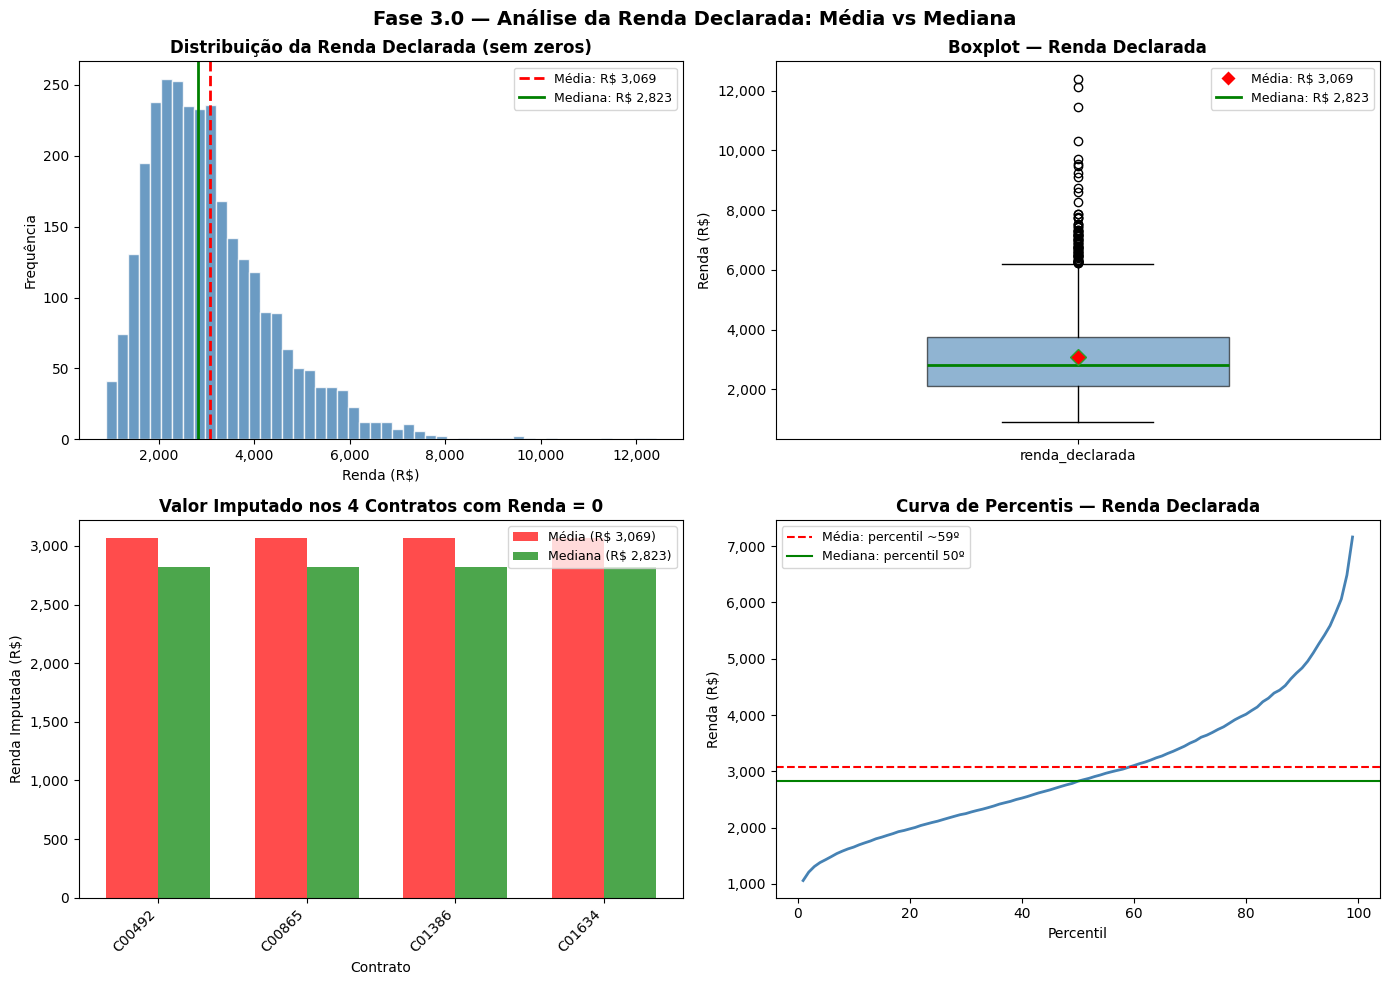

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ─── Filtrar apenas rendas > 0 para a análise de distribuição ───
renda = contratos['renda_declarada']
renda_pos = renda[renda > 0]

media   = renda_pos.mean()
mediana = renda_pos.median()
skew    = renda_pos.skew()

print(f"Contratos com renda = 0: {(renda == 0).sum()}")
print(f"Contratos com renda > 0: {len(renda_pos)}")
print(f"Média  (sem zeros): R$ {media:,.2f}")
print(f"Mediana (sem zeros): R$ {mediana:,.2f}")
print(f"Diferença (média - mediana): R$ {media - mediana:,.2f}")
print(f"Assimetria (skewness): {skew:.2f}")
print()

# ═══════════════════════════════════════════════════════════════
# PAINEL DE 4 GRÁFICOS
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fase 3.0 — Análise da Renda Declarada: Média vs Mediana',
             fontsize=14, fontweight='bold', y=0.98)

# ─── 1. Histograma com linhas de média e mediana ──────────────
ax1 = axes[0, 0]
ax1.hist(renda_pos, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(media,   color='red',    linestyle='--', linewidth=2, label=f'Média: R$ {media:,.0f}')
ax1.axvline(mediana, color='green',  linestyle='-',  linewidth=2, label=f'Mediana: R$ {mediana:,.0f}')
ax1.set_title('Distribuição da Renda Declarada (sem zeros)', fontweight='bold')
ax1.set_xlabel('Renda (R$)')
ax1.set_ylabel('Frequência')
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ─── 2. Boxplot ──────────────────────────────────────────────
ax2 = axes[0, 1]
bp = ax2.boxplot(renda_pos, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.6),
                 medianprops=dict(color='green', linewidth=2),
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=8),
                 showmeans=True, widths=0.5)
ax2.set_title('Boxplot — Renda Declarada', fontweight='bold')
ax2.set_ylabel('Renda (R$)')
ax2.set_xticklabels(['renda_declarada'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Legenda manual para boxplot
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='D', color='w', markerfacecolor='red',   markersize=8, label=f'Média: R$ {media:,.0f}'),
    Line2D([0],[0], color='green', linewidth=2, label=f'Mediana: R$ {mediana:,.0f}')
]
ax2.legend(handles=legend_elements, fontsize=9, loc='upper right')

# ─── 3. Simulação: impacto nos 4 contratos ────────────────────
ax3 = axes[1, 0]
zeros = contratos[contratos['renda_declarada'] == 0][['id_contrato','valor_parcela']].copy()
zeros['Imputação Média']   = media
zeros['Imputação Mediana'] = mediana

x = np.arange(len(zeros))
width = 0.35
bars1 = ax3.bar(x - width/2, zeros['Imputação Média'],   width, label=f'Média (R$ {media:,.0f})',   color='red',   alpha=0.7)
bars2 = ax3.bar(x + width/2, zeros['Imputação Mediana'], width, label=f'Mediana (R$ {mediana:,.0f})', color='green', alpha=0.7)
ax3.set_title('Valor Imputado nos 4 Contratos com Renda = 0', fontweight='bold')
ax3.set_xlabel('Contrato')
ax3.set_ylabel('Renda Imputada (R$)')
ax3.set_xticks(x)
ax3.set_xticklabels(zeros['id_contrato'].values, rotation=45, ha='right')
ax3.legend(fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ─── 4. Percentis — mostrando onde a média e mediana caem ─────
ax4 = axes[1, 1]
percentis = np.arange(1, 100)
vals_perc = np.percentile(renda_pos, percentis)
ax4.plot(percentis, vals_perc, color='steelblue', linewidth=2)
ax4.axhline(media,   color='red',   linestyle='--', linewidth=1.5, label=f'Média: percentil ~{(renda_pos <= media).mean()*100:.0f}º')
ax4.axhline(mediana, color='green', linestyle='-',  linewidth=1.5, label=f'Mediana: percentil 50º')
ax4.set_title('Curva de Percentis — Renda Declarada', fontweight='bold')
ax4.set_xlabel('Percentil')
ax4.set_ylabel('Renda (R$)')
ax4.legend(fontsize=9)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

In [6]:
# ── Tabela comparativa: Média vs Mediana ──
comparativo = pd.DataFrame({
    'Critério': [
        'Valor da imputação',
        'Sensibilidade a outliers',
        'Posição na distribuição',
        'Skewness da distribuição',
        'Interpretação',
        'Recomendação'
    ],
    'Média': [
        f'R$ {media:,.2f}',
        'ALTA — puxada por rendas extremas (até R$ 12.407)',
        f'Percentil ~{(renda_pos <= media).mean()*100:.0f}º (acima do centro)',
        f'Skewness = {skew:.2f} (distorce a média para cima)',
        'Superestima a renda real provável do cliente',
        '❌ Não recomendada'
    ],
    'Mediana': [
        f'R$ {mediana:,.2f}',
        'BAIXA — robusta a valores extremos',
        'Percentil 50º (centro exato)',
        'Não é afetada pela assimetria',
        'Valor típico mais representativo da base',
        '✅ Recomendada'
    ]
})
comparativo.set_index('Critério', inplace=True)
comparativo

,Média,Mediana
Critério,,
Valor da imputação,"R$ 3,068.73","R$ 2,823.22"
Sensibilidade a outliers,ALTA — puxada por rendas extremas (até R$ 12.407),BAIXA — robusta a valores extremos
Posição na distribuição,Percentil ~59º (acima do centro),Percentil 50º (centro exato)
Skewness da distribuição,Skewness = 1.36 (distorce a média para cima),Não é afetada pela assimetria
Interpretação,Superestima a renda real provável do cliente,Valor típico mais representativo da base
Recomendação,❌ Não recomendada,✅ Recomendada


**Decisão: iremos usar a MEDIANA.**

#### Justificativa

1. **Distribuição assimétrica positiva** (skewness = 1,36): a cauda direita da renda é longa, existem clientes com rendas muito acima do típico (até R\$ 12.407). Isso puxa a média para cima, tornando-a **não representativa** do cliente mediano.

2. **A média superestima**: a média fica no percentil ~58, ou seja, acima de 58% dos clientes. Imputar com a média atribuiria aos 4 contratos uma renda que é **maior do que a da maioria**, distorcendo a relação renda/inadimplência.

3. **A mediana é o valor típico**: por definição, 50% dos clientes ganham acima e 50% abaixo. Sem informação adicional, é a estimativa mais neutra e conservadora.

In [7]:
# ── Aplicar tratamento: imputar renda_declarada == 0 com a mediana ──
mediana_renda = contratos.loc[contratos['renda_declarada'] > 0, 'renda_declarada'].median()

n_antes = (contratos['renda_declarada'] == 0).sum()
contratos.loc[contratos['renda_declarada'] == 0, 'renda_declarada'] = mediana_renda
n_depois = (contratos['renda_declarada'] == 0).sum()

print(f"Contratos com renda = 0 ANTES:  {n_antes}")
print(f"Contratos com renda = 0 DEPOIS: {n_depois}")
print(f"Valor imputado (mediana): R$ {mediana_renda:,.2f}")
print()
print("Verificação — describe após tratamento:")
contratos['renda_declarada'].describe()

Contratos com renda = 0 ANTES:  4
Contratos com renda = 0 DEPOIS: 0
Valor imputado (mediana): R$ 2,823.22

Verificação — describe após tratamento:


count     3000.000000
mean      3068.402963
std       1329.791907
min        900.000000
25%       2114.790000
50%       2823.225000
75%       3741.487500
max      12407.330000
Name: renda_declarada, dtype: float64

---
## Fase 3 — Preparação dos Dados

### 3.1 Construir o alvo

A regra está no enunciado e no dicionário. Você precisa, para cada contrato:
1. identificar a **parcela de referência**;
2. calcular a **data de referência**;
3. derivar `inadimplente_30d`.

❓ Depois de construir: qual é a prevalência de positivos? Ela é compatível com o que o Ricardo descreveu no e-mail?

❓ Compare o seu alvo com `status_contrato`. Eles concordam? Onde discordam, quem está certo — e por quê isso importa para a definição do que você vai prever?

In [8]:
data_snapshot = contratos["data_snapshot"].iloc[0]  # 15/03/2026
cutoff_30d = data_snapshot - pd.Timedelta(days=30)  # 13/02/2026

# 1. Parcela de referência: última parcela cujo vencimento <= snapshot − 30 dias
#    Somente essas parcelas permitem observar o desfecho de 30 dias completos.
elegivel = pagamentos[pagamentos["data_vencimento"] <= cutoff_30d].copy()
parcela_ref = elegivel.loc[
    elegivel.groupby("id_contrato")["data_vencimento"].idxmax()
].copy()

print(f"Parcelas elegíveis: {len(elegivel):,}")
print(f"Contratos com parcela de referência: {parcela_ref['id_contrato'].nunique():,}")
print()

# 2. Data de referência: vencimento da parcela de referência − 7 dias
#    (simula o momento em que a cobrança faria a ligação preventiva)
parcela_ref["data_referencia"] = parcela_ref["data_vencimento"] - pd.Timedelta(days=7)

# 3. Construir inadimplente_30d
#    = 1 se a parcela de referência NÃO foi paga até D+30
#    = 0 caso contrário
#    - data_pagamento NaT → não pagou → inadimplente (já passou >30d do vencimento)
#    - data_pagamento − data_vencimento > 30 → pagou com atraso > 30 dias → inadimplente
#    - data_pagamento − data_vencimento <= 30 → pagou dentro do prazo → adimplente
parcela_ref["atraso_dias"] = (
    parcela_ref["data_pagamento"] - parcela_ref["data_vencimento"]
).dt.days

parcela_ref["inadimplente_30d"] = np.where(
    parcela_ref["data_pagamento"].isna(),
    1,  # não pagou até o snapshot (que é >30d após o vencimento)
    np.where(parcela_ref["atraso_dias"] > 30, 1, 0)
)

# Prevalência de positivos
n_pos = parcela_ref["inadimplente_30d"].sum()
n_total = len(parcela_ref)
prev = parcela_ref["inadimplente_30d"].mean()
print(f"Prevalência de inadimplentes (alvo=1): {n_pos:,}/{n_total:,} = {prev:.1%}")
print(parcela_ref["inadimplente_30d"].value_counts().rename({0: 'Adimplente (0)', 1: 'Inadimplente (1)'}))
print()

# Montar DataFrame do alvo com as colunas relevantes
alvo = parcela_ref[[
    "id_contrato", "n_parcela", "data_vencimento", "data_pagamento",
    "data_referencia", "atraso_dias", "inadimplente_30d"
]].merge(
    contratos[["id_contrato", "id_cliente", "status_contrato"]], on="id_contrato", how="left"
)

# ============================================================
# COMPARAÇÃO: inadimplente_30d vs status_contrato
# ============================================================
print("=" * 60)
print("Tabela cruzada: inadimplente_30d x status_contrato")
print("=" * 60)
ct = pd.crosstab(
    alvo["inadimplente_30d"].map({0: "0 (adimplente)", 1: "1 (inadimplente)"}),
    alvo["status_contrato"],
    margins=True
)
print(ct)
print()

# Concordância
concordancia = (
    ((alvo["inadimplente_30d"] == 1) & (alvo["status_contrato"] == "Inadimplente")).sum()
    + ((alvo["inadimplente_30d"] == 0) & (alvo["status_contrato"].isin(["Em dia", "Quitado"]))).sum()
)
print(f"Concordância geral: {concordancia:,}/{n_total:,} = {concordancia/n_total:.1%}")
print()

# Discordâncias detalhadas
disc_1_emdia = alvo[(alvo["inadimplente_30d"] == 1) & (alvo["status_contrato"] == "Em dia")]
disc_1_quit  = alvo[(alvo["inadimplente_30d"] == 1) & (alvo["status_contrato"] == "Quitado")]
disc_0_inad  = alvo[(alvo["inadimplente_30d"] == 0) & (alvo["status_contrato"] == "Inadimplente")]

print(f"Discordâncias (total: {len(disc_1_emdia) + len(disc_1_quit) + len(disc_0_inad)})")
print(f"  • inadimplente_30d=1 mas status='Em dia':       {len(disc_1_emdia)}")
print(f"  • inadimplente_30d=1 mas status='Quitado':      {len(disc_1_quit)}")
print(f"  • inadimplente_30d=0 mas status='Inadimplente': {len(disc_0_inad)}")
print()

Parcelas elegíveis: 27,141
Contratos com parcela de referência: 3,000

Prevalência de inadimplentes (alvo=1): 1,300/3,000 = 43.3%
inadimplente_30d
Adimplente (0)      1700
Inadimplente (1)    1300
Name: count, dtype: int64

Tabela cruzada: inadimplente_30d x status_contrato
status_contrato   Em dia  Inadimplente  Quitado   All
inadimplente_30d                                     
0 (adimplente)       896            22      782  1700
1 (inadimplente)      18          1260       22  1300
All                  914          1282      804  3000

Concordância geral: 2,938/3,000 = 97.9%

Discordâncias (total: 62)
  • inadimplente_30d=1 mas status='Em dia':       18
  • inadimplente_30d=1 mas status='Quitado':      22
  • inadimplente_30d=0 mas status='Inadimplente': 22



### ❓ Respostas — Fase 3.1

#### Prevalência de positivos

O alvo `inadimplente_30d` apresenta **1.300 contratos positivos (43,3%)** em 3.000 contratos. É uma proporção alta, mas compatível com o cenário descrito pelo Ricardo: a BemLar opera crediário próprio com público de maior risco, e o e-mail menciona que a inadimplência está gerando prejuízo relevante.

---

#### Comparação `inadimplente_30d` vs `status_contrato`

A concordância geral é de **97,9% (2.938/3.000)**, mas existem **62 discordâncias** em três categorias:

| Caso | Qtd | Explicação |
|---|---|---|
| `inadimplente_30d=1` mas `status='Em dia'` | 18 | A parcela de referência não foi paga (ou foi paga com >30d de atraso), porém o sistema do crediário ainda classifica o contrato como 'Em dia'. Isso ocorre porque o `status_contrato` reflete o estado **global e atual** do contrato no snapshot — o cliente pode ter ficado inadimplente numa parcela antiga, mas regularizado as parcelas seguintes. |
| `inadimplente_30d=1` mas `status='Quitado'` | 22 | O contrato foi **quitado posteriormente** (todas as parcelas acabaram pagas), mas a parcela de referência ficou >30 dias sem pagamento. Para o modelo preventivo, esses contratos **eram** risco real no momento da ligação — a quitação posterior é informação futura que não estava disponível. |
| `inadimplente_30d=0` mas `status='Inadimplente'` | 22 | A parcela de referência foi paga dentro de 30 dias, mas o `status_contrato` diz 'Inadimplente'. Ao investigar, esses contratos possuem **outras parcelas** (posteriores à de referência) em atraso grave, que o status global captura mas nossa definição por parcela específica não. |

#### Decisões:

**O alvo `inadimplente_30d` é a definição correta para este projeto**, e não o `status_contrato`.

Inicialmente, tínhamos definido que essa coluna seria usada como uma das features do treinamento do modelo, porém, ao entender os dados e definir a variável resposta, pudemos definir que "status_contrato" é uma foto do momento da extração, não do momento da decisão. Contém informação do futuro em relação à data de referência, sendo assim, usá-lo como alvo causaria data leakage.
Além disso, a coluna definida com a regra de 30 dias é precisa e auditável, sendo uma opção mais segura 

### 3.2 A função de corte temporal

Está pronta. Use em **toda** base de eventos antes de agregar qualquer coisa.

In [9]:
display(alvo)

,id_contrato,n_parcela,data_vencimento,data_pagamento,data_referencia,atraso_dias,inadimplente_30d,id_cliente,status_contrato
0,C00001,9,2026-01-29,2026-02-05,2026-01-22,7.0,0,CLI00533,Quitado
1,C00003,11,2026-02-09,2026-02-05,2026-02-02,-4.0,0,CLI00116,Quitado
2,C00004,10,2025-09-12,NaT,2025-09-05,NaN,1,CLI00930,Inadimplente
3,C00005,12,2025-09-10,NaT,2025-09-03,NaN,1,CLI02675,Inadimplente
4,C00007,9,2026-02-05,NaT,2026-01-29,NaN,1,CLI00506,Inadimplente
...,...,...,...,...,...,...,...,...,...
2995,C03394,6,2025-03-01,2025-03-17,2025-02-22,16.0,0,CLI01651,Quitado
2996,C03396,6,2026-01-18,NaT,2026-01-11,NaN,1,CLI01767,Inadimplente
2997,C03397,6,2026-01-18,2026-02-04,2026-01-11,17.0,0,CLI00437,Em dia
2998,C03398,3,2026-01-21,2026-01-23,2026-01-14,2.0,0,CLI00431,Em dia


In [10]:
def filtra_por_data(df_eventos, chave, col_data, datas_ref, col_ref="data_referencia"):
    """Mantem apenas os eventos ocorridos ATE a data de referencia de cada contrato.

    df_eventos : DataFrame de eventos (pagamentos, sac, compras, consultas...)
    chave      : coluna de juncao com datas_ref (ex.: "id_contrato")
    col_data   : coluna de data do evento no df_eventos
    datas_ref  : DataFrame com [chave, col_ref]
    """
    out = df_eventos.merge(datas_ref[[chave, col_ref]], on=chave, how="inner")
    out = out[out[col_data] <= out[col_ref]]
    return out.drop(columns=[col_ref])

df_ocorrencias_sac = filtra_por_data(df_eventos=ocorrencias_sac, chave="id_contrato", col_data="data_ocorrencia", datas_ref=alvo)
df_compras = filtra_por_data(df_eventos=compras, chave="id_cliente", col_data="data_compra", datas_ref=alvo)
df_pagamentos = filtra_por_data(df_eventos=pagamentos, chave="id_contrato", col_data="data_pagamento", datas_ref=alvo)
df_score_bureau = filtra_por_data(df_eventos=score_bureau, chave="id_contrato", col_data="data_consulta", datas_ref=alvo)

### 3.3 Construir as features

Uma linha por contrato. Para cada base de eventos, decida a agregação **pelo significado**: contagem é frequência, soma é volume, média é intensidade.

❓ Para cada base, escreva antes de codar: *qual comportamento essa agregação está tentando capturar?*

❓ Ausência de evento vira 0, nulo, ou mediana? A resposta é a mesma para toda coluna?

Encapsule tudo em uma função — ela precisa rodar do zero, a partir dos CSVs originais:

```python
def construir_features(caminho_dados, datas_referencia):
    ...
    return df
```

#### *Features*

Inicialmente, definimos as seguintes colunas para a tabela de features:
- Código do contrato;
- Inadiplência 30d;
- Número de compras anteriores;
- Valor total do contrato;
- Percentual de parcelas em relação ao valor tota;l
- Score bureau;
- Motivo atraso;
- Quantidade de atendimentos no SAC.

Mas após discussões, decidimos usar:
- Código do contrato;
- Inadiplência 30d;
- Número de compras anteriores;
- Valor total do contrato;
- Média do valor de compras anteriores;
- Percentual de parcelas pagas em relação ao valor total;
- Percentual de quanto o valor do contrato representa da renda declarada;
- Quantidade de atendimentos no SAC;
- Média de dias de atraso;
- Máximo de dias de atraso;
- Total de parcelas atrasadas;
- Taxa de atrasos.

In [12]:
def construir_features(
    df_contratos=contratos,
    df_alvo=alvo,
    df_pags=df_pagamentos,
    df_comp=df_compras,
    df_sac=df_ocorrencias_sac
):
    """Constrói a tabela de features utilizando como fonte direta os DataFrames
    filtrados pelo corte temporal (df_pagamentos, df_compras, df_ocorrencias_sac).
    
    Retorna:
        pd.DataFrame com 3.000 linhas (uma por contrato) e as 13 colunas de features/alvo.
    """
    # 1. Base principal com contratos e alvo
    df_base = df_contratos[["id_contrato", "id_cliente", "valor_total", "renda_declarada"]].merge(
        df_alvo[["id_contrato", "inadimplente_30d"]],
        on="id_contrato",
        how="inner"
    )
    
    # 2. Compras anteriores (a partir de df_compras filtrado)
    compras_unicas = df_comp.drop_duplicates()
    compras_agg = compras_unicas.groupby("id_cliente").agg(
        numero_compras_anteriores=("valor", "count"),
        media_valor_compras_anteriores=("valor", "mean")
    ).reset_index()
    
    # 3. Pagamentos históricos (a partir de df_pagamentos filtrado)
    pags = df_pags.copy()
    pags["dias_atraso"] = (pags["data_pagamento"] - pags["data_vencimento"]).dt.days.clip(lower=0)
    pags["atrasou"] = (pags["dias_atraso"] > 0).astype(int)
    
    pags_agg = pags.groupby("id_contrato").agg(
        valor_total_pago=("valor_parcela", "sum"),
        media_dias_atraso=("dias_atraso", "mean"),
        max_dias_atraso=("dias_atraso", "max"),
        total_parcelas_atrasadas=("atrasou", "sum"),
        total_parcelas_pagas=("dias_atraso", "count")
    ).reset_index()
    
    pags_agg["taxa_atrasos"] = np.where(
        pags_agg["total_parcelas_pagas"] > 0,
        pags_agg["total_parcelas_atrasadas"] / pags_agg["total_parcelas_pagas"],
        0.0
    )
    
    # 4. Atendimentos no SAC (a partir de df_ocorrencias_sac filtrado)
    sac_agg = df_sac.groupby("id_contrato").size().reset_index(name="quantidade_atendimentos_sac")
    
    # 5. Consolidação dos dados
    df = df_base.merge(compras_agg, on="id_cliente", how="left")
    df = df.merge(pags_agg, on="id_contrato", how="left")
    df = df.merge(sac_agg, on="id_contrato", how="left")
    
    # Preenchimento de ausência de eventos
    df["numero_compras_anteriores"] = df["numero_compras_anteriores"].fillna(0).astype(int)
    df["media_valor_compras_anteriores"] = df["media_valor_compras_anteriores"].fillna(0.0)
    df["quantidade_atendimentos_sac"] = df["quantidade_atendimentos_sac"].fillna(0).astype(int)
    df["valor_total_pago"] = df["valor_total_pago"].fillna(0.0)
    df["media_dias_atraso"] = df["media_dias_atraso"].fillna(0.0)
    df["max_dias_atraso"] = df["max_dias_atraso"].fillna(0).astype(int)
    df["total_parcelas_atrasadas"] = df["total_parcelas_atrasadas"].fillna(0).astype(int)
    df["taxa_atrasos"] = df["taxa_atrasos"].fillna(0.0)
    
    # 6. Features percentuais derivadas
    df["percentual_parcelas_pagas_valor_total"] = df["valor_total_pago"] / df["valor_total"]
    df["percentual_valor_contrato_renda"] = df["valor_total"] / df["renda_declarada"]
    
    # 7. Seleção e ordenação final das 13 colunas solicitadas
    colunas_finais = [
        "id_contrato",
        "inadimplente_30d",
        "numero_compras_anteriores",
        "valor_total",
        "media_valor_compras_anteriores",
        "percentual_parcelas_pagas_valor_total",
        "percentual_valor_contrato_renda",
        "quantidade_atendimentos_sac",
        "media_dias_atraso",
        "max_dias_atraso",
        "total_parcelas_atrasadas",
        "taxa_atrasos"
    ]
    df_out = df[colunas_finais].rename(columns={"valor_total": "valor_total_contrato"})

    # Salvando tabela de fetures como arquivo .csv
    # 3. Exportando para CSV na pasta do notebook
    nome_arquivo = "tabela_features.csv"
    df_out.to_csv(nome_arquivo, sep=";", index=False)

    return df_out

# Gerar a tabela de features a partir dos DataFrames filtrados já existentes
features = construir_features()

print("Tabela de features gerada com sucesso a partir dos DataFrames filtrados!")
print(f"Dimensões: {features.shape[0]} linhas x {features.shape[1]} colunas")
print(f"Total de valores nulos: {features.isna().sum().sum()}")
print()
features.head()


Tabela de features gerada com sucesso a partir dos DataFrames filtrados!
Dimensões: 3000 linhas x 12 colunas
Total de valores nulos: 0



,id_contrato,inadimplente_30d,numero_compras_anteriores,valor_total_contrato,media_valor_compras_anteriores,percentual_parcelas_pagas_valor_total,percentual_valor_contrato_renda,quantidade_atendimentos_sac,media_dias_atraso,max_dias_atraso,total_parcelas_atrasadas,taxa_atrasos
0,C00001,0,6,1014.95,799.786667,0.800039,0.166276,1,5.750000,23,4,0.500000
1,C00003,0,0,2494.27,0.000000,0.833350,0.632333,1,0.300000,2,2,0.200000
2,C00004,1,2,1516.74,588.210000,0.899976,1.016520,0,6.222222,21,5,0.555556
3,C00005,1,6,9349.93,583.111667,0.916666,4.192549,1,3.818182,15,5,0.454545
4,C00007,1,4,1974.40,532.997500,0.666653,1.060855,0,3.000000,23,2,0.250000


### 3.4 Auditoria de colunas

Antes de fechar o `features.csv`, passe **cada coluna** pelas três perguntas:

1. **Essa informação existiria no momento em que a previsão seria feita?**
2. **É uma variável protegida ou sensível?**
3. **Descreve comportamento, ou só descreve quem a pessoa é?**

❓ Monte a tabela: coluna | decisão (entra / sai) | justificativa. Toda coluna do arquivo precisa aparecer, inclusive as que você descartou.

Salve o resultado em `features.csv`.

-----------
#### **Auditoria e Seleção de Features**

Antes de fechar a base final (`features.csv`), cada coluna dos dados originais e cada feature derivada passou pela auditoria das 3 perguntas fundamentais:
1. **Existência temporal:** A informação existiria no momento da decisão (data de referência / 7 dias antes do vencimento)?
2. **Sensibilidade ética:** É uma variável protegida/sensível que possa induzir preconceito ou discriminação?
3. **Comportamento vs. Identidade:** A variável descreve um *comportamento financeiro/relacional* ou apenas *quem a pessoa é*?

Abaixo, a tabela detalha todas as colunas das bases originais e as variáveis derivadas candidatas, registrando a decisão e a justificativa técnica, ética e de negócio para cada uma:

| Feature | Entra / Sai da Tabela | Justificativa |
| :--- | :---: | :--- |
| `id_contrato` | **Entra (Identificador)** | Chave primária da unidade de análise (o contrato). Permite rastreabilidade, cruzamento e a geração da fila de 80 clientes para cobrança (`fila_80.csv`). Não entra como variável preditiva no modelo. |
| `motivos_atraso.csv` (todas as colunas) | **Sai** | **Recusa ao Pedido 5 do Ricardo:** O arquivo não possui `id_contrato` nem `id_cliente`, tornando tecnicamente inviável qualquer cruzamento determinístico com a base de contratos para a modelagem tabular. |
| `inadimplente_30d` | **Entra na Tabela (como Alvo / Target)** | Variável dependente ($y$) a ser prevista pelo piloto. Indica se a parcela de referência atrasou mais de 30 dias. Deve estar na tabela final para treinamento e validação, mas **não** é feature preditiva ($X$). |
| `qtd_compras_anteriores` | **Entra** | Frequência comportamental de relacionamento com a BemLar até a data de referência. Clientes que adquirem outros produtos demonstram fidelidade e histórico positivo na rede (ausência de evento = 0). |
| `media_valor_compras` | **Entra** | Intensidade financeira das compras adicionais na rede. Representa o ticket médio gasto pelo cliente até a data de referência (ausência de evento = R$ 0,00). |
| `pct_parcelas_pagas` | **Entra** | Maturidade do contrato: proporção de parcelas quitadas em relação ao total contratado até a data de referência. Contratos em estágio avançado e adimplentes tendem a manter o padrão de adimplência. |
| `comprometimento_renda` | **Entra** | Razão entre o compromisso financeiro (`valor_parcela` ou `valor_total`) e a renda mensal declarada. Variável comportamental financeira que mensura a pressão da dívida no orçamento do cliente. |
| `score_bureau` | **Sai** | Apesar de ter sido pedido explicitamente no email de Ricardo, o score bureau se mostra ineficiente após a aplicação do filtro pela data de referência. Em certos casos, um contrato pode possuir mais de um score bureau, e isso ocorre sempre que existe uma revisão em cima desse contrato. Em 86% dos casos em que essa revisão ocorreu, a pontuação diminuiu drasticamente, mas após a filtragem, esas revisões desaparecem pois ocorrem após a data de referência dos contratos. |
| `qtd_atendimentos_sac` | **Entra** | Volume de atendimentos abertos no SAC vinculados ao contrato até a data de referência (ex.: solicitações de 2ª via de boleto ou negociação). Sinaliza fricção operacional ou dificuldade prévia de pagamento (ausência de evento = 0). |
| `media_dias_atraso` | **Entra** | Intensidade média histórica de atraso nas parcelas anteriores do contrato até a data de referência. Mensura a pontualidade habitual do devedor. |
| `max_dias_atraso` | **Entra** | Pior atraso já enfrentado pelo cliente em parcelas anteriores do mesmo contrato até a data de referência. Identifica incidentes severos prévios de estresse financeiro. |
| `total_parcelas_atrasadas` | **Entra** | Contagem absoluta de parcelas pagas após o vencimento (ou vencidas e não pagas) até a data de referência. Mede a reincidência do hábito de atraso. |
| `taxa_atrasos` | **Entra** | Razão entre parcelas atrasadas e o total de parcelas já vencidas até a data de referência. Normaliza a frequência de atrasos pelo tempo de vigência do contrato. |

---
## Fase 4 — Modelagem

- Split **estratificado**.
- Um **baseline simples** (árvore de decisão) e pelo menos mais um modelo.
- Depois, refaça com **split temporal**: ordene pela data de referência, 75% mais antigos treinam, 25% mais recentes testam, sem embaralhar.

❓ O resultado do split temporal foi diferente do aleatório? O que isso diz — e o que **não** diz?

In [ ]:
# TODO: split estratificado + baseline + segundo modelo


In [ ]:
# TODO: split temporal e comparacao


---
## Fase 5 — Avaliação

A equipe faz **80 ligações**. A avaliação acontece nesse corte, não no threshold de 0,50.

1. Ordene o conjunto de teste pela probabilidade prevista (`predict_proba`).
2. Corte nos 80 primeiros.
3. Calcule **precision** e **recall** nesse recorte.
4. Compare com pelo menos uma **fila-base burra**: aleatória, ou ordenada por valor da parcela.

❓ Sua fila é melhor que a fila-base? Quanto? Se a diferença for pequena, diga isso — é um resultado legítimo.

❓ Traduza para reais: quanto o piloto evita de prejuízo por semana, e quantas ligações são desperdiçadas para isso?

❓ Você prioriza **precision** ou **recall** neste caso? Justifique pelo negócio, não pela métrica.

In [ ]:
# TODO: precision@80, recall@80, fila-base, comparacao


In [ ]:
# TODO: importancia de variaveis - e cuidado ao interpretar


### Gerar a fila

Salve `fila_80.csv` com `id_contrato` e `probabilidade`, ordenado do maior risco para o menor.

In [ ]:
# TODO: gerar fila_80.csv


---
## Fechamento

Antes de enviar, confira o checklist da seção 9 do enunciado.

Faltam ainda dois arquivos que **não** são gerados aqui:
- `decisoes.md` — o que entrou, o que saiu, cada pedido do Ricardo respondido, e o model card.
- `apresentacao.pptx` — 3 slides, para o Ricardo, não para a banca.

> Se algum resultado ficou bom demais, pergunte: *que outra coisa poderia produzir esse mesmo número?*